<a href="https://colab.research.google.com/github/Soutrik-77/Stress_Optimizer_Surrogate/blob/main/Stress_Surrogate_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import torch
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

'2.10.0+cpu'

In [15]:
l_train = torch.tensor([1,2,3,4,5,6,8,10,12], dtype=torch.float32)
L_train = torch.log(l_train)
print(L_train)
str_train = torch.tensor([41.667, 666.72, 3374, 10667, 26042, 54000, 170670, 416670, 864000], dtype=torch.float32)
STR_train = torch.log(str_train)
print(STR_train)
STR_ana_train = 3.72970 + 4 * L_train
print(STR_ana_train)

tensor([0.0000, 0.6931, 1.0986, 1.3863, 1.6094, 1.7918, 2.0794, 2.3026, 2.4849])
tensor([ 3.7297,  6.5024,  8.1239,  9.2749, 10.1675, 10.8967, 12.0475, 12.9401,
        13.6693])
tensor([ 3.7297,  6.5023,  8.1241,  9.2749, 10.1675, 10.8967, 12.0475, 12.9400,
        13.6693])


In [16]:
l_test = torch.tensor([13,14,15,16], dtype=torch.float32)
L_test = torch.log(l_test)
STR_ana_test = 3.72970 + 4 * L_test

In [17]:
def plot_predictions(train_data=L_train,
                        train_labels=STR_ana_train,
                        test_data=L_test,
                        test_labels=STR_ana_test,
                        predictions=None):

  plt.figure(figsize=(10,7))
  plt.scatter(train_data, train_labels, c="b", s=8, label="Training data")
  plt.scatter(test_data, test_labels, c="g", s=8, label="Testing data")
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=12, label="Predictions")
  plt.legend(prop={"size":14});

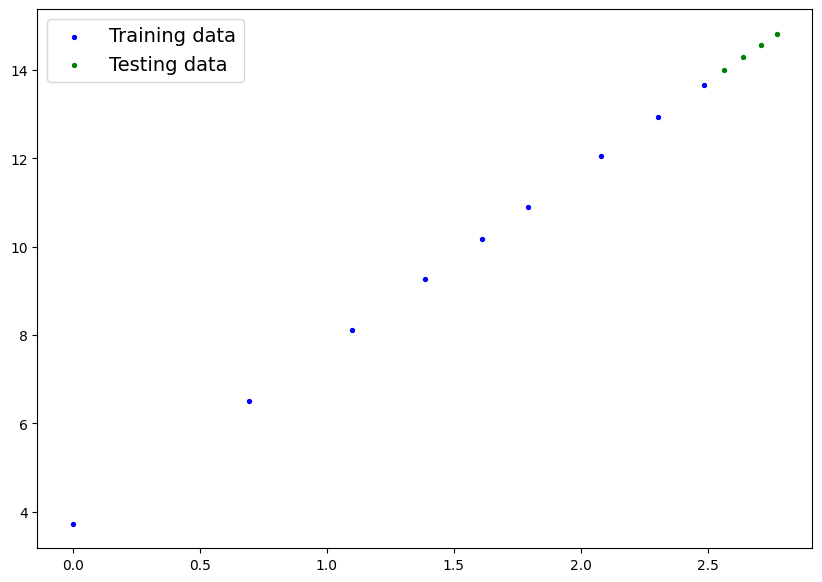

In [18]:
plot_predictions()

In [19]:
from torch import nn
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)

In [20]:
model_0 = LinearRegressionModel()
model_0
list(model_0.parameters())

with torch.inference_mode():
  STR_preds = model_0(L_test.unsqueeze(1))

STR_preds

tensor([[2.1964],
        [2.2493],
        [2.2986],
        [2.3447]])

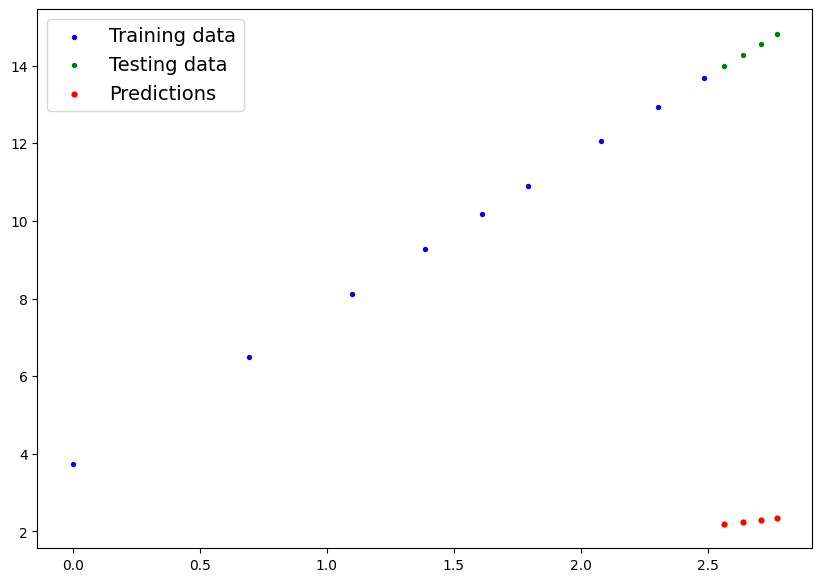

In [21]:
plot_predictions(predictions=STR_preds)

In [22]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(
    model_0.parameters(),
    lr=0.01,              # Learning rate
    weight_decay=0.05     # Ridge penalty (λ) - try 0.01, 0.1, 1.0
)

epochs = 1000
for epoch in range(epochs):
    # Training mode
    model_0.train()

    # Forward pass
    STR_pred = model_0(L_train.unsqueeze(1))
    loss = loss_fn(STR_pred, STR_train.unsqueeze(1))

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Evaluation mode
    model_0.eval()
    with torch.inference_mode():
        test_pred = model_0(L_test.unsqueeze(1))
        test_loss = loss_fn(test_pred, STR_ana_test.unsqueeze(1))

    # Print progress
    if epoch % 10 == 0:
     print(f" Epoch = {epoch:3d} | Loss : {loss:.4f} | Test_loss : {test_loss: .4f}")
     print(model_0.state_dict())

 Epoch =   0 | Loss : 74.6091 | Test_loss :  125.8842
OrderedDict({'linear.weight': tensor([[0.9986]]), 'linear.bias': tensor([0.5294])})
 Epoch =  10 | Loss : 16.7343 | Test_loss :  24.9713
OrderedDict({'linear.weight': tensor([[2.9067]]), 'linear.bias': tensor([1.6536])})
 Epoch =  20 | Loss : 3.9669 | Test_loss :  4.4220
OrderedDict({'linear.weight': tensor([[3.7871]]), 'linear.bias': tensor([2.1956])})
 Epoch =  30 | Loss : 1.1033 | Test_loss :  0.5798
OrderedDict({'linear.weight': tensor([[4.1883]]), 'linear.bias': tensor([2.4654])})
 Epoch =  40 | Loss : 0.4355 | Test_loss :  0.0214
OrderedDict({'linear.weight': tensor([[4.3663]]), 'linear.bias': tensor([2.6075])})
 Epoch =  50 | Loss : 0.2645 | Test_loss :  0.0198
OrderedDict({'linear.weight': tensor([[4.4405]]), 'linear.bias': tensor([2.6896])})
 Epoch =  60 | Loss : 0.2109 | Test_loss :  0.0686
OrderedDict({'linear.weight': tensor([[4.4665]]), 'linear.bias': tensor([2.7430])})
 Epoch =  70 | Loss : 0.1873 | Test_loss :  0.0971

In [23]:
STR_preds_new = model_0(L_test.unsqueeze(1))

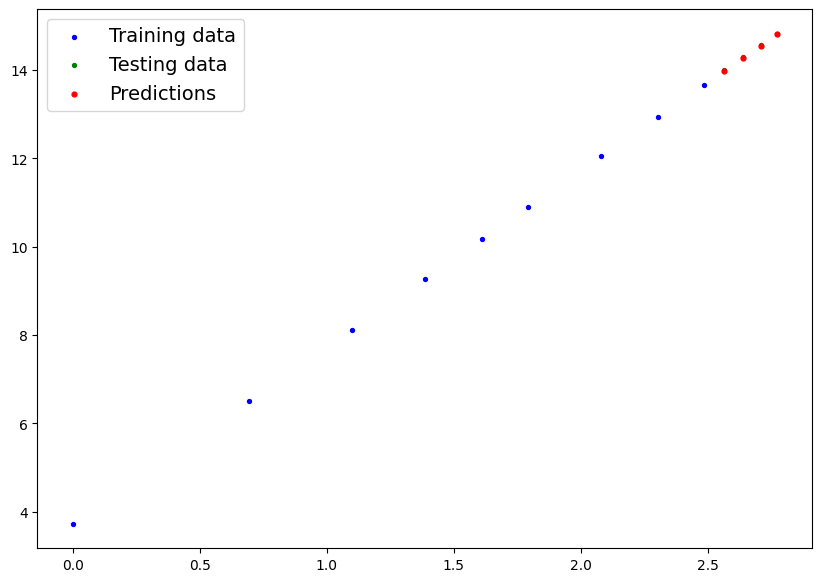

In [24]:
plot_predictions(predictions=STR_preds_new.detach().squeeze())

In [25]:
STR_preds_new

tensor([[13.9716],
        [14.2733],
        [14.5541],
        [14.8168]], grad_fn=<AddmmBackward0>)

In [26]:
exp_STR_preds =torch.exp(STR_preds_new.detach().squeeze())
exp_STR_preds

tensor([1168974.8750, 1580537.2500, 2092965.2500, 2721729.7500])

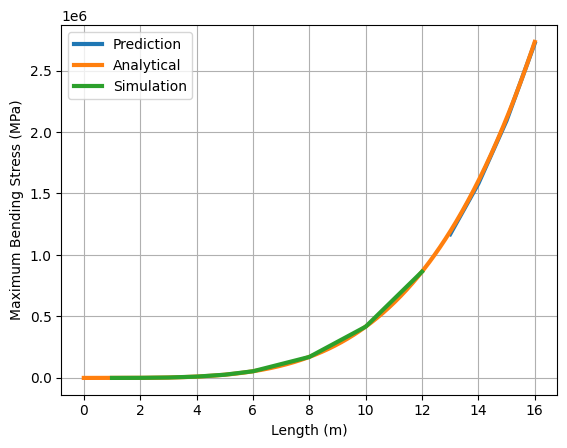

In [28]:
import matplotlib.pyplot as plt
import numpy as np
L1 = np.linspace(0, 16, 1000)
Stress_A = 41.7 * (L1**4)
plt.plot(l_test, exp_STR_preds, linewidth =3)
plt.plot(L1, Stress_A, linewidth=3)
plt.plot(l_train, str_train, linewidth=3)
plt.xlabel("Length (m)")
plt.ylabel("Maximum Bending Stress (MPa)")
plt.legend(["Prediction","Analytical", "Simulation"])
plt.grid(True)
plt.show()